# Spaceship Titanic - Kaggle Competition

# Step 1: Loading and Combining Data

In [1]:
# Importing
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
# loading Datasets
train = pd.read_csv(r"C:\Users\gs602\Downloads\train.csv")
test = pd.read_csv(r"C:\Users\gs602\Downloads\test.csv")

train['is_train'] = 1
test['is_train'] = 0

df = pd.concat([train, test], axis=0).reset_index(drop=True)

In [6]:
#EDA(Exploratory Data Analysis)
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,is_train
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,1
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,1
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,1
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,1


In [7]:
df.shape

(12970, 15)

In [8]:
df.isnull().sum()

PassengerId        0
HomePlanet       288
CryoSleep        310
Cabin            299
Destination      274
Age              270
VIP              296
RoomService      263
FoodCourt        289
ShoppingMall     306
Spa              284
VRDeck           268
Name             294
Transported     4277
is_train           0
dtype: int64

In [10]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
12965    False
12966    False
12967    False
12968    False
12969    False
Length: 12970, dtype: bool

In [11]:
df.drop_duplicates(inplace = True)

# Step 2: Feature Engineering

In [13]:
# 1. Cabin -> Deck, Num, Side
df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)

# 2. Total Spent (Aggregation)
bill_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df[bill_cols] = df[bill_cols].fillna(0) # Logic: If NaN, they likely spent 0
df['TotalSpent'] = df[bill_cols].sum(axis=1)

# 3. PassengerId -> Group
df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])

# Step 3: Handling Missing Values

In [14]:
# Categorical/Boolean: Fill with Mode (Most Frequent)
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerical (Age): Fill with Median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Convert booleans to binary (0/1)
df['CryoSleep'] = df['CryoSleep'].astype(int)
df['VIP'] = df['VIP'].astype(int)

# Step 4: Encoding & Feature Selection

In [15]:
# One-Hot Encoding for categorical features
df = pd.get_dummies(df, columns=['HomePlanet', 'Destination', 'Deck', 'Side'])

# Drop ID strings and high-cardinality columns for the baseline
drop_cols = ['PassengerId', 'Cabin', 'Name', 'Group', 'Num']
df_model = df.drop(columns=drop_cols)

# Step 5: Training & Validation

In [19]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

# 1. Upgrade the Model
# Gradient Boosting is generally superior to Random Forest for this competition.
# Tuning n_estimators and learning_rate is the key to accuracy.
model = GradientBoostingClassifier(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42
)

# 2. Implement Cross-Validation
# Instead of one 80/20 split, this splits the data 5 times (K-Fold).
# It ensures your accuracy is stable across different subsets of the data.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print(f"Mean CV Accuracy: {cv_results.mean():.4f}")
print(f"Accuracy Standard Deviation: {cv_results.std():.4f}")

# 3. Final Fit on the FULL training set
# To get the best possible predictions for the test set, 
# fit the model on 100% of your training data after validation.
model.fit(X, y)

# 4. Generate Predictions for Submission
# Ensure test_proc has the exact same columns as X (training features)
test_preds = model.predict(test_proc)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_preds.astype(bool) # Kaggle expects True/False
})

submission.to_csv('submission_final.csv', index=False)
print("Final submission file created!")

Mean CV Accuracy: 0.8049
Accuracy Standard Deviation: 0.0066
Final submission file created!


# Step 6 : Data Visualization

Text(0.5, 1.0, 'HomePlanet vs Transported')

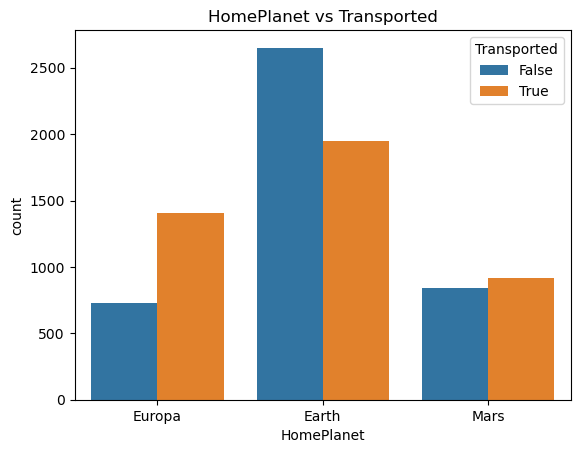

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=train, x='HomePlanet', hue='Transported')
plt.title('HomePlanet vs Transported')

Text(0.5, 1.0, 'CryoSleep vs Transported')

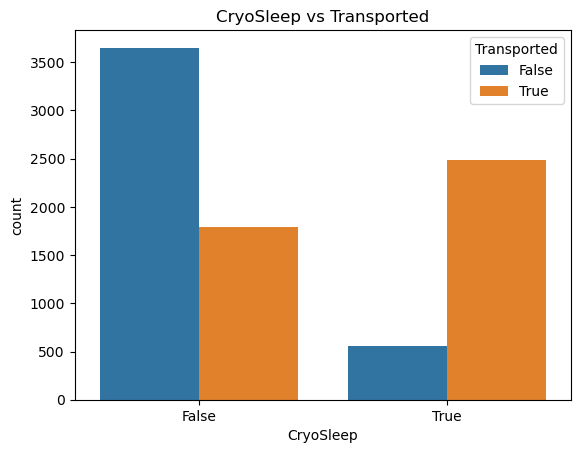

In [30]:
sns.countplot(data=train, x='CryoSleep', hue='Transported')
plt.title('CryoSleep vs Transported')

Text(0.5, 1.0, 'Destination vs Transported')

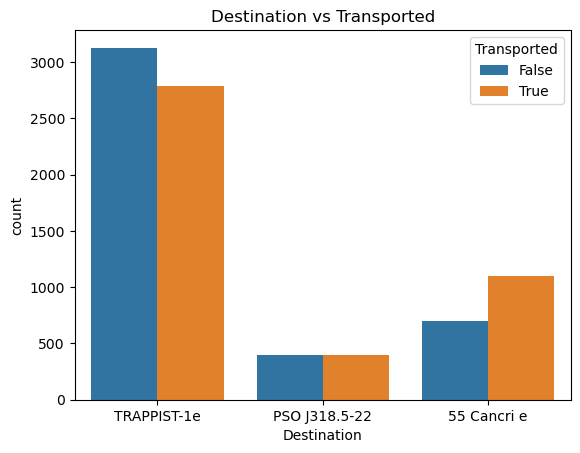

In [31]:
sns.countplot(data=train, x='Destination', hue='Transported')
plt.title('Destination vs Transported')

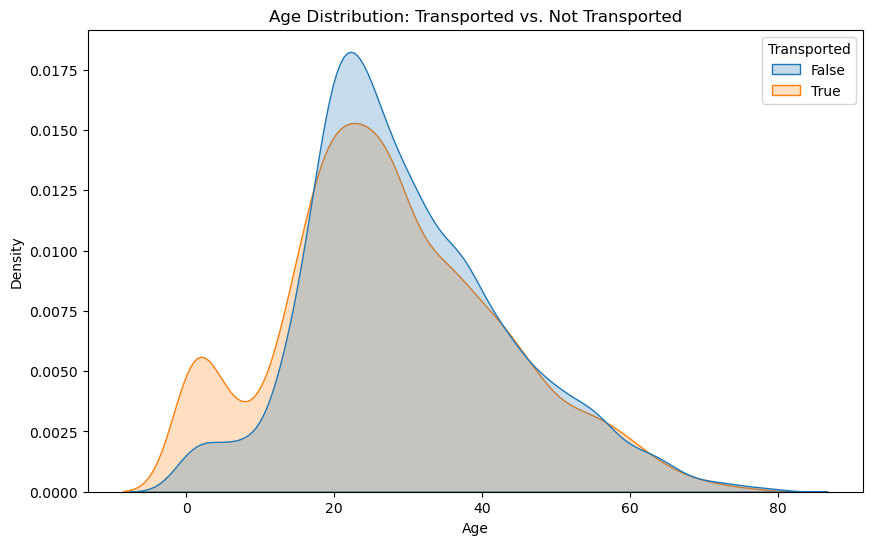

In [34]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train, x='Age', hue='Transported', fill=True)
plt.title('Age Distribution: Transported vs. Not Transported')
plt.show()

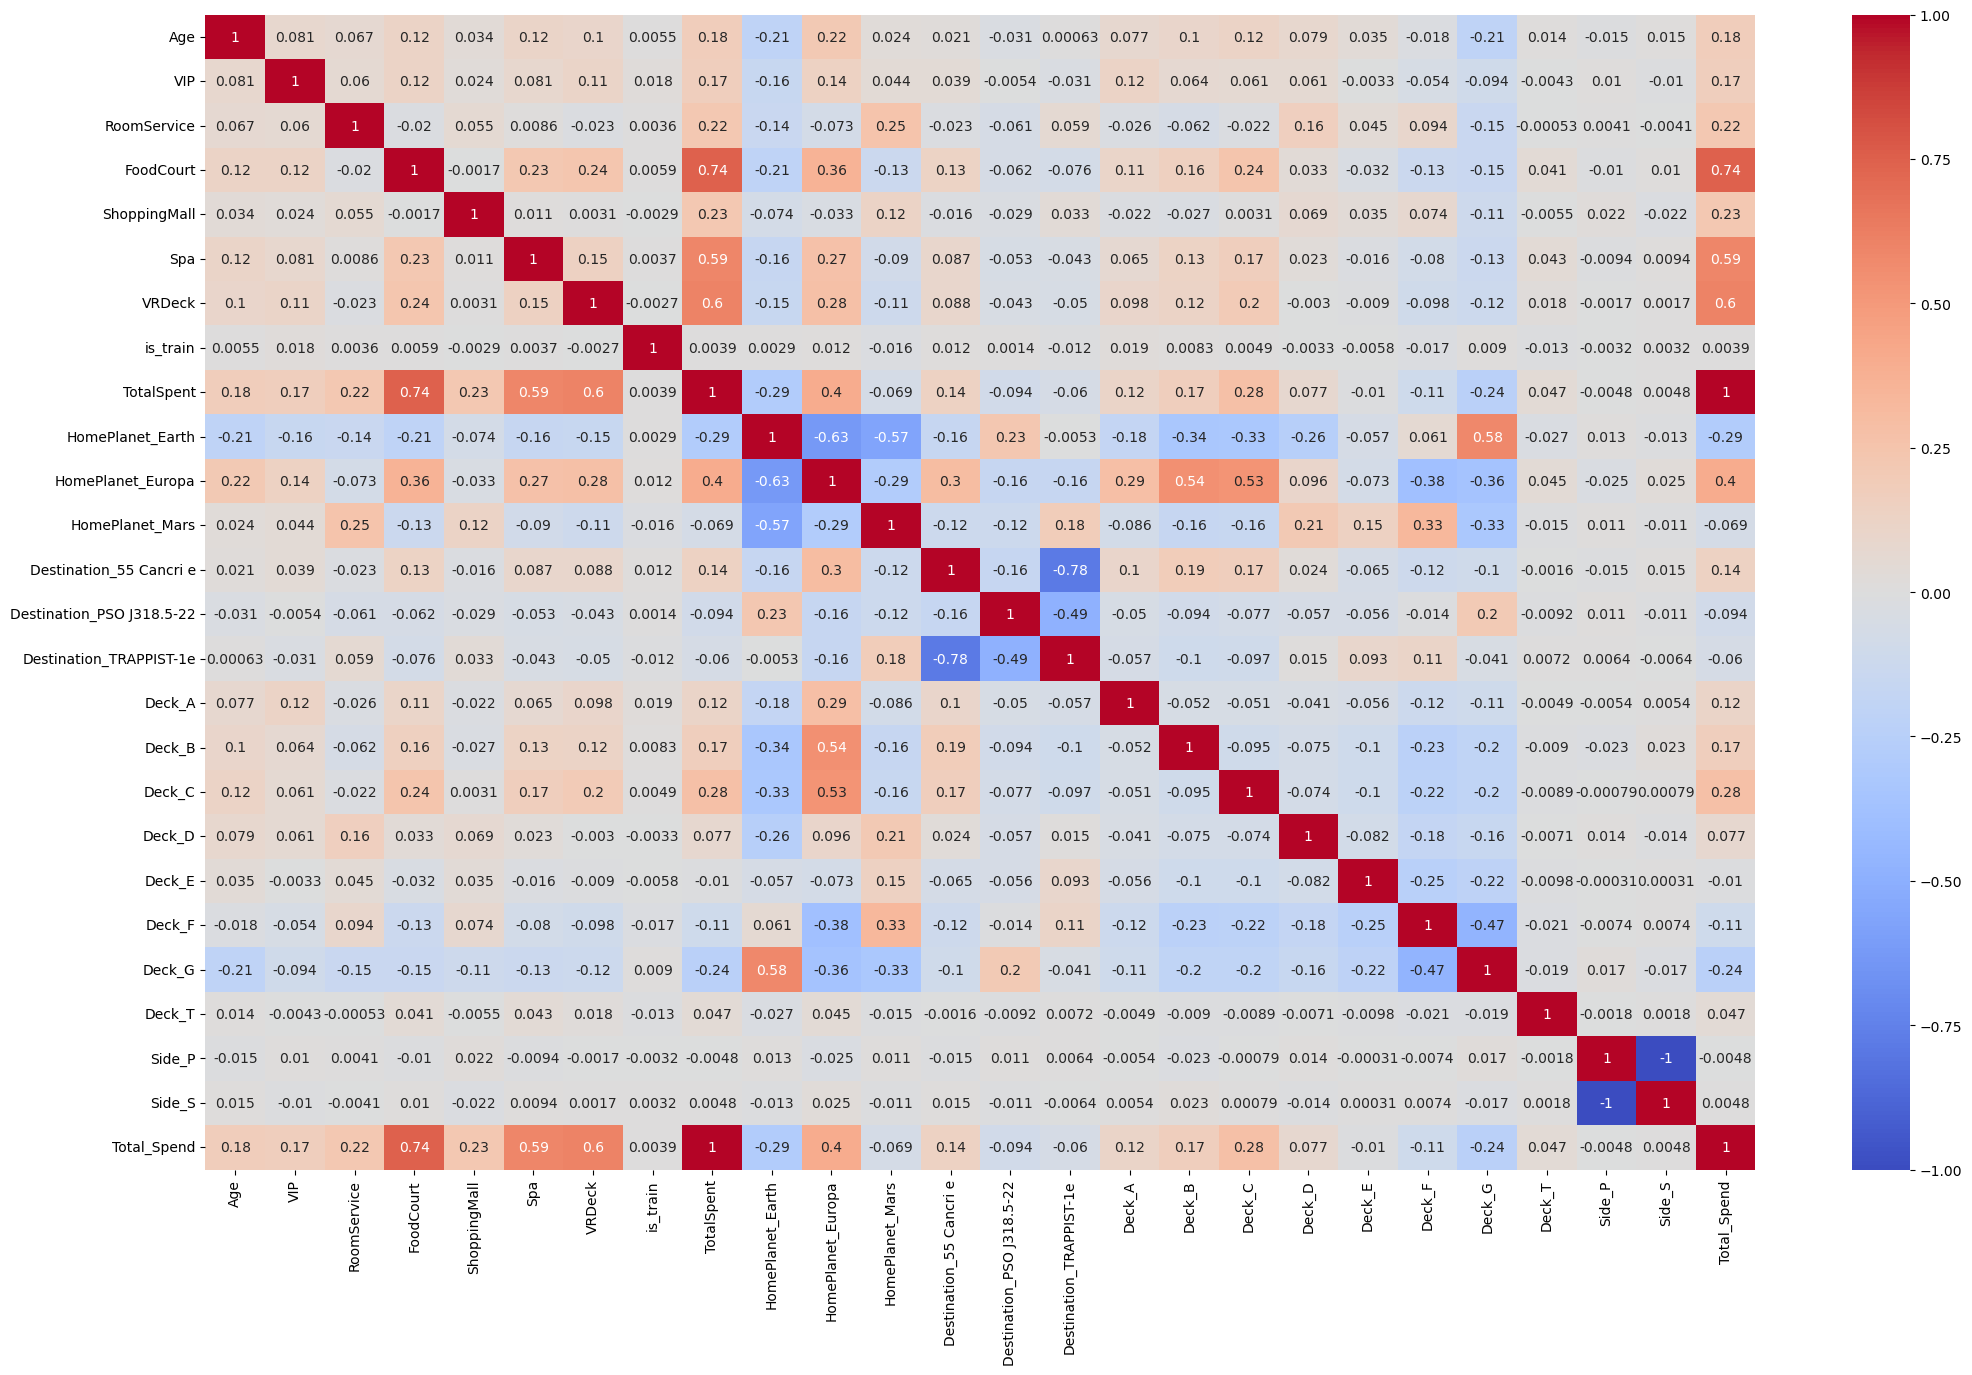

In [46]:
plt.figure(figsize=(25, 15))
sns.heatmap(df.corr(numeric_only = True) , annot=True , cmap="coolwarm")
plt.show()